<a href="https://colab.research.google.com/github/serendipity343/Machine-learning/blob/Task-1%262/task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
This colab worksheet provides a starting point for Task 1 (the natural language processing assignment).

In [ ]:
import google
google.colab.drive.mount('/content/drive')

Mounted at /content/drive


# Load the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Load the data using np.load
data = pd.read_csv('/content/drive/MyDrive/350/spam_detection_training_data.csv')

# Extract the text
text = data['text'].values
# and the labels
labels = data['label'].values

print(text.shape, labels.shape)

test_data = pd.read_csv('/content/drive/MyDrive/350/spam_detection_test_data.csv')
test_text = test_data['text'].values
print(test_text.shape)

(3619,) (3619,)
(1552,)


# Data Visualisation
Here's an example of how to display the text based on its label.

In [ ]:
def print_text(text, label):
  if label == 0:
    print (text, '\nis not spam!')
  else:
    print (text, '\nis spam!')

import numpy as np
idx = np.random.randint(0, text.shape[0])
print_text(text[idx], labels[idx])

Subject: re : code # yr - 983795 - o
hi ,
i sent you an email last week and i ' d like to confirm everything now .
please read the info below and let me know if you have any questions .
we are accepting your m . ortgage application . if you have b - ad c . redit ,
it ' s ok . you can get a $ 200 , 000 loan for a $ 350 per month payment .
approval process will only take 1 minute . just visit the link below and
fill out the short form .
thank you
best regards ,
manager : margarita pruitt
usa broker group
yael has a beautiful new home in new jersey -
and you can too !
future options :
sterlinglenders . com / st . html
 
is spam!


# Calculating Confusion Matrix and exporting results

In [ ]:
from sklearn.metrics import confusion_matrix

def confusion_matrix(true_label, pred_label):
  """
  Calculate the confusion matrix for your predicted labels. See https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
  :param pred_label: Array of predicted labels
  :param true_label: Array of corresponding ground truth (test) labels
  :return: Confusion matrix whose i-th row and j-th column entry indicates the number of samples with true label being i-th class and predicted label being j-th class.
  """
  return confusion_matrix(true_label, pred_label)


In [ ]:
def save_as_csv(pred_labels):
    """
    Save the labels out as a .csv file
    :pred_labels: numpy array of shape (no_test_labels,) to be saved
    :param location: Directory to save results.csv in. Default to current working directory
    """
    assert pred_labels.shape[0]==1552, 'wrong number of labels, should be 1552 test labels'
    np.savetxt('/content/drive/MyDrive/350/results_task1.csv', pred_labels, delimiter=',')


In [ ]:
# Preprocess training text
text = np.array([t.lower().replace(r'[^a-z ]', '') for t in text])
# Preprocess test text
test_text = np.array([t.lower().replace(r'[^a-z ]', '') for t in test_text])

In [ ]:
# 4 Split Training Data
from sklearn.model_selection import train_test_split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    text, labels, test_size=0.2, random_state=42
)

In [ ]:
# Step 5: Feature Extraction with TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)
X_test = vectorizer.transform(test_text)

In [ ]:
# Step 6: Train the Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, train_labels)

LogisticRegression()

In [ ]:
# Step 7: Evaluate on Validation Set
from sklearn.metrics import confusion_matrix, accuracy_score
val_predictions = model.predict(X_val)
accuracy = accuracy_score(val_labels, val_predictions)

print(f'Validation Accuracy: {accuracy:.4f}')

cm = confusion_matrix(val_labels, val_predictions)
print('Confusion Matrix:')
print(cm)

Validation Accuracy: 0.9820
Confusion Matrix:
[[500   9]
 [  4 211]]


Validation Accuracy: 0.9820
Validation Precision: 0.9756
Validation Recall: 0.9819
Validation F1 Score: 0.9786
Confusion Matrix:
[[500   9]
 [  4 211]]


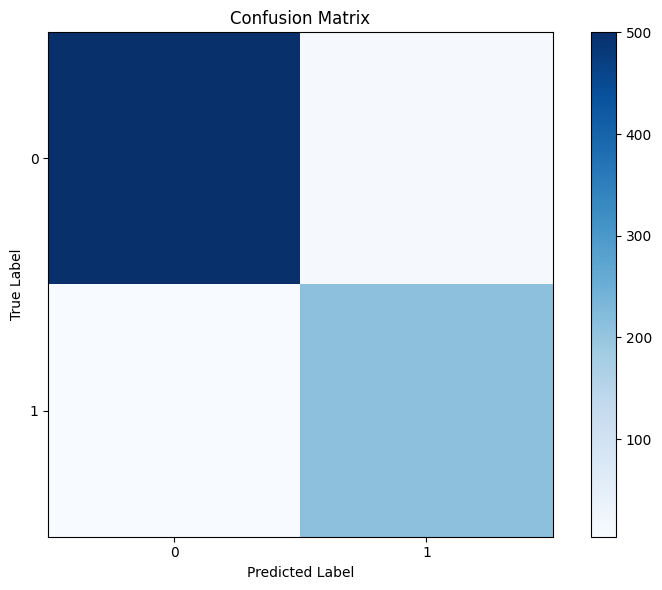

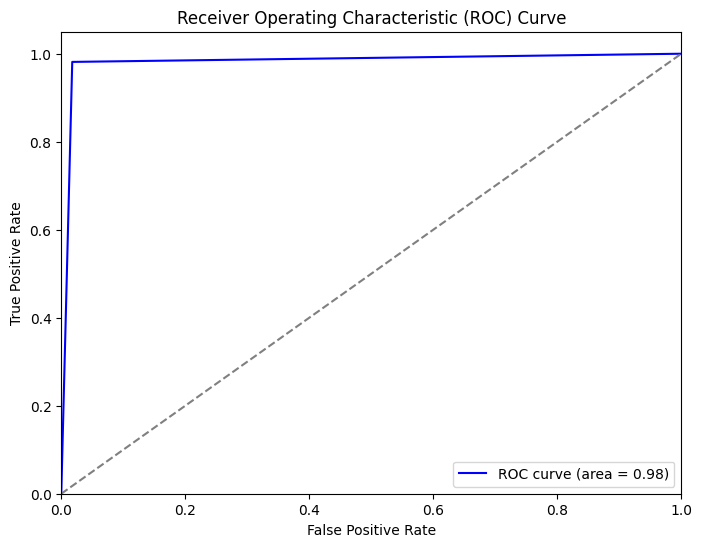

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Step 7: Evaluate on Validation Set
val_predictions = model.predict(X_val)

# Calculate accuracy
accuracy = accuracy_score(val_labels, val_predictions)
print(f'Validation Accuracy: {accuracy:.4f}')

# Calculate precision, recall and F1 score
precision = precision_score(val_labels, val_predictions, average='macro')
# 'macro' for multi-class, use 'binary' for binary classification
recall = recall_score(val_labels, val_predictions, average='macro')
f1 = f1_score(val_labels, val_predictions, average='macro')

print(f'Validation Precision: {precision:.4f}')
print(f'Validation Recall: {recall:.4f}')
print(f'Validation F1 Score: {f1:.4f}')

# Confusion Matrix
cm = confusion_matrix(val_labels, val_predictions)
print('Confusion Matrix:')
print(cm)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(np.unique(val_labels)))
plt.xticks(tick_marks, np.unique(val_labels))
plt.yticks(tick_marks, np.unique(val_labels))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# If it is a binary classification problem, draw the ROC curve
if len(np.unique(val_labels)) == 2:  # Draw the ROC curve for the binary classification problem
    fpr, tpr, thresholds = roc_curve(val_labels, val_predictions)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()


In [ ]:
# Step 9 Identify misclassified samples
misclassified = pd.DataFrame({
    'text': val_texts[val_predictions != val_labels],
    'label': val_labels[val_predictions != val_labels]
})
print("Sample misclassified cases:")
print(misclassified.head())

# Save top 10 failure cases
failure_cases = misclassified.head(10)
failure_cases.to_csv('failure_cases.csv', index=False)
print('Failure cases saved to failure_cases.csv')

Sample misclassified cases:
                                                text  label
0  subject: holiday party - save the date\r\nplea...      0
1  subject: dear all\r\nif you wish to find out m...      0
2  subject: \r\nhe [ llqyo\r\nde = ar home owner ...      1
3  subject: digitize your memories with compaq sc...      0
4  subject: president @ juno . com : exciting new...      0
Failure cases saved to failure_cases.csv


In [ ]:
#Step 10: Predict Test Data and Save Results
test_predictions = model.predict(X_test)

save_as_csv(test_predictions)
print('Test predictions saved to results_task1.csv')

Test predictions saved to results_task1.csv


In [ ]:
# Step 11: Optional Analysis of a Failure Case
if not misclassified.empty:
    fail_text = misclassified.iloc[0]['text']
    fail_label = misclassified.iloc[0]['label']
    print_text(fail_text, fail_label)

subject: holiday party - save the date
please click on the link below
save the date 
is not spam!
